#1. Can we use Bagging for regression problems?
Yes, Bagging (Bootstrap Aggregating) can be used for regression problems.

# 2.  What is the difference between multiple model training and single model training?
Single model training uses one algorithm fitted on the entire dataset, while multiple model training (like ensembles) builds several models on data subsets or variations, then combines their outputs.

# 3.  Explain the concept of feature randomness in Random Forest.
Feature randomness is a core mechanism in Random Forests that enhances tree diversity beyond simple bagging.At each node split in a decision tree, Random Forest doesn't evaluate all features; instead, it randomly selects a subset (typically
p
for classification or
p/3 for regression, where
p is total features). The best split is then chosen only from this random subset, preventing dominant features from always being picked and decorrelating trees.

# 4. What is OOB (Out-of-Bag) Score?
OOB (Out-of-Bag) score is a built-in validation metric unique to bagging-based ensembles like Random Forests.

# 5. How can you measure the importance of features in a Random Forest model?
Feature importance in Random Forest models measures how much each feature contributes to the model's predictive power across the ensemble of trees.

Main Method: Mean Decrease Impurity (Gini Importance)
For each tree, calculate the total reduction in node impurity (e.g., Gini index for classification) from splits using a feature, weighted by samples reaching that node. Average these impurity decreases across all trees; higher values indicate greater importance.

# 6.  Explain the working principle of a Bagging Classifier.
## **Working Principle**
Bootstrap sampling creates diverse subsets from the original dataset by sampling with replacement (about 63% unique data per sample). Each subset trains an independent base classifier (e.g., decision tree), often in parallel, allowing weak learners to capture varied patterns.

Final predictions aggregate via majority voting across all classifiers, reducing variance and overfitting compared to a single model.

#7.  How do you evaluate a Bagging Classifier’s performance?
Bagging Classifiers are evaluated using standard classification metrics and their unique internal validation method.



# 8. How does a Bagging Regressor work?
A Bagging Regressor builds an ensemble of base regression models (typically decision trees) on bootstrap samples and averages their predictions for stable, low-variance outputs.

# 9. What is the main advantage of ensemble techniques?
Ensemble techniques mainly improve predictive performance by reducing variance and overfitting compared to single models.


# 10. What is the main challenge of ensemble methods?
Ensemble methods face high computational demands as their main challenge.


# 11. Explain the key idea behind ensemble techniques.
The key principle is wisdom of the crowd: diverse weak learners (e.g., decision trees) make independent errors that cancel out when aggregated via averaging (regression) or voting (classification). This reduces bias and variance, as seen in bagging's bootstrap samples and Random Forest's feature randomness from prior discussion.

# 12. What is a Random Forest Classifier?
A Random Forest Classifier is an ensemble machine learning algorithm that builds multiple decision trees on bootstrapped data subsets and uses majority voting for class predictions.

# 13. What are the main types of ensemble techniques?
Ensemble techniques primarily fall into three main types: Bagging, Boosting, and Stacking.
## **Bagging**
Trains models independently on bootstrap samples (e.g., Random Forest with feature randomness), then aggregates via voting or averaging to reduce variance.[prior context]
​

# **Boosting**
Builds models sequentially, with each focusing on previous errors (e.g., AdaBoost, Gradient Boosting), weighting mistakes to lower bias.

# **Stacking**
Combines predictions from diverse base models using a meta-learner, leveraging strengths of heterogeneous algorithms.

# 14. What is ensemble learning in machine learning?
Ensemble learning in machine learning combines multiple base models (often weak learners like decision trees) to produce more accurate and robust predictions than a single model alone.


# 15. When should we avoid using ensemble methods?
Avoid ensemble methods when computational resources, interpretability, or data size are severely limited.


# 16. How does Bagging help in reducing overfitting?
Bagging reduces overfitting primarily by averaging predictions from multiple high-variance models trained on bootstrap data subsets, lowering overall variance.

# 17.  Why is Random Forest better than a single Decision Tree?
Random Forest outperforms a single Decision Tree by leveraging ensemble bagging and feature randomness to reduce overfitting and boost accuracy.

#18.What is the role of bootstrap sampling in Bagging?
Bootstrap sampling is the core mechanism in Bagging that creates diverse training subsets for base models.
Role in Bagging
It draws random samples with replacement from the original dataset (typically same size as original), resulting in each bootstrap set containing ~63% unique data points while some are duplicated. About 37% of data becomes out-of-bag (OOB) samples, naturally excluded from each model's training for free validation.[prior context].



# 19. What are some real-world applications of ensemble techniques?

Ensemble techniques power many real-world machine learning applications by combining models for better accuracy and robustness.

##**Healthcare**
Used for disease prediction (e.g., cancer, diabetes via Random Forests), medical imaging analysis like MRI/ECG classification, and patient readmission risk assessment.

##**Finance**
Detects credit card fraud, assesses loan risks/credit scoring, predicts stock prices, and aids portfolio management.

# 20.  What is the difference between Bagging and Boosting?
Bagging and Boosting are both ensemble methods but differ fundamentally in training approach and error handling.

# 21.  Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                          n_estimators=10, random_state=42, oob_score=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(f"OOB Score: {model.oob_score_:.4f}")


Model Accuracy: 1.0000
OOB Score: 0.9238


# 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, test_size=0.3, random_state=42)

model = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42),
                         n_estimators=10, random_state=42, oob_score=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")
print(f"OOB Score (R^2): {model.oob_score_:.4f}")


Test MSE: 3237.5265
OOB Score (R^2): 0.2807


# 23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.


In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)  # 0.9708
print("OOB Score:", model.oob_score_)  # 0.9548

# Top features
importances = model.feature_importances_
top_indices = np.argsort(importances)[::-1][:10]
for i in top_indices:
    print(cancer.feature_names[i], importances[i])


Accuracy: 0.9707602339181286
OOB Score: 0.9547738693467337
mean concave points 0.1419344436315119
worst concave points 0.12713637963171595
worst area 0.11821685833472201
mean concavity 0.08055701642634591
worst radius 0.07797474929691814
worst perimeter 0.07429212194132524
mean perimeter 0.060092333477412795
mean area 0.05381045367561502
worst concavity 0.04107957505964944
mean radius 0.032311888273301004


# 24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load dataset
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target,
                                                    test_size=0.3, random_state=42)

# Single Decision Tree
dt = DecisionTreeRegressor(random_state=42, max_depth=None)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

# Random Forest (100 trees)
rf = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Results
print("DECISION TREE: MSE =", round(dt_mse, 2), "R² =", round(dt_r2, 3))
print("RANDOM FOREST: MSE =", round(rf_mse, 2), "R² =", round(rf_r2, 3))
print("OOB Score:", round(rf.oob_score_, 3))


DECISION TREE: MSE = 5697.79 R² = -0.055
RANDOM FOREST: MSE = 2859.64 R² = 0.47
OOB Score: 0.429


# 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.


In [5]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=42)

# Train with OOB enabled
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

# OOB score (built-in validation)
print(f"OOB Score: {rf.oob_score_:.4f}")  # e.g., 0.9524

# Compare with test accuracy
y_pred = rf.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")  # e.g., 1.0000


OOB Score: 0.9429
Test Accuracy: 1.0000


# 26. Train a Bagging Classifier using SVM as a base estimator and print accuracy.


In [6]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Bagging Classifier with SVM base estimator
svm = SVC(kernel='rbf', gamma='scale', random_state=42)
model = BaggingClassifier(estimator=svm, n_estimators=10, random_state=42, oob_score=True)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# Results
print(f"Bagging SVM Accuracy: {accuracy:.4f}")
print(f"OOB Score: {model.oob_score_:.4f}")


Bagging SVM Accuracy: 1.0000
OOB Score: 0.9524


# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.


In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size=0.3, random_state=42)

# Test different numbers of trees
n_trees = [10, 50, 100, 500]
results = {}

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=True)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    oob = rf.oob_score_

    results[n] = {'accuracy': accuracy, 'oob_score': oob}
    print(f"Trees: {n:3d} | Test Acc: {accuracy:.4f} | OOB: {oob:.4f}")

# Summary table
print("\n" + "="*50)
print("SUMMARY:")
for n, scores in results.items():
    print(f"{n:3d} trees: {scores['accuracy']:.4f} (OOB: {scores['oob_score']:.4f})")


Trees:  10 | Test Acc: 0.9649 | OOB: 0.9372
Trees:  50 | Test Acc: 0.9708 | OOB: 0.9497
Trees: 100 | Test Acc: 0.9708 | OOB: 0.9548
Trees: 500 | Test Acc: 0.9708 | OOB: 0.9523

SUMMARY:
 10 trees: 0.9649 (OOB: 0.9372)
 50 trees: 0.9708 (OOB: 0.9497)
100 trees: 0.9708 (OOB: 0.9548)
500 trees: 0.9708 (OOB: 0.9523)


# 28. Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.


In [ ]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Generate binary classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                          n_redundant=5, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Bagging Classifier with Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
model = BaggingClassifier(estimator=lr, n_estimators=10, random_state=42, oob_score=True)
model.fit(X_train, y_train)

# Predict probabilities and compute AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Bagging Logistic Regression AUC: {auc_score:.4f}")
print(f"OOB Score: {model.oob_score_:.4f}")


# 29. Train a Random Forest Regressor and analyze feature importance scores.


In [8]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Load Diabetes dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

# Predictions and metrics
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test R²: {r2:.3f}")
print(f"OOB Score: {rf.oob_score_:.3f}")

# Feature importance analysis
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': diabetes.feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 10 Feature Importances:")
print(feature_importance_df.head(10).round(4))


Test MSE: 2859.64
Test R²: 0.470
OOB Score: 0.429

Top 10 Feature Importances:
  feature  importance
2     bmi      0.4000
8      s5      0.1666
3      bp      0.1048
9      s6      0.0714
6      s3      0.0617
0     age      0.0586
4      s1      0.0492
5      s2      0.0471
7      s4      0.0294
1     sex      0.0111


# 30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.


In [9]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size=0.3, random_state=42)

# Bagging Classifier (Decision Trees)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                           n_estimators=100, random_state=42, oob_score=True)
bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)
bagging_acc = accuracy_score(y_test, bagging_pred)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Results
print("MODEL COMPARISON")
print("=" * 40)
print(f"Bagging Accuracy:  {bagging_acc:.4f}  (OOB: {bagging.oob_score_:.4f})")
print(f"Random Forest Accuracy: {rf_acc:.4f}  (OOB: {rf.oob_score_:.4f})")
print(f"RF Improvement: {((rf_acc - bagging_acc)/bagging_acc)*100:.1f}%")


MODEL COMPARISON
Bagging Accuracy:  0.9591  (OOB: 0.9397)
Random Forest Accuracy: 0.9708  (OOB: 0.9548)
RF Improvement: 1.2%


# 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.


In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create Random Forest and GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train with GridSearch
grid_search.fit(X_train, y_train)

# Best model results
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("BEST HYPERPARAMETERS:")
print(grid_search.best_params_)
print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 81 candidates, totalling 405 fits
BEST HYPERPARAMETERS:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation Accuracy: 0.9572
Test Accuracy: 0.9708

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        63
           1       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



# 32. Train a Bagging Regressor with different numbers of base estimators and compare performance.

In [11]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Load dataset
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

# Test different numbers of estimators
n_estimators_list = [10, 50, 100, 200]
results = []

for n_estimators in n_estimators_list:
    # Train Bagging Regressor
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=n_estimators,
        random_state=42,
        oob_score=True
    )
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    oob_r2 = model.oob_score_

    results.append({
        'n_estimators': n_estimators,
        'test_mse': mse,
        'oob_r2': oob_r2
    })

    print(f"{n_estimators:3d} estimators | MSE: {mse:.1f} | OOB R²: {oob_r2:.3f}")

# Summary DataFrame
import pandas as pd
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print(results_df.round(2))


 10 estimators | MSE: 3237.5 | OOB R²: 0.281
 50 estimators | MSE: 2987.0 | OOB R²: 0.424
100 estimators | MSE: 2908.8 | OOB R²: 0.426
200 estimators | MSE: 2854.9 | OOB R²: 0.433

   n_estimators  test_mse  oob_r2
0            10   3237.53    0.28
1            50   2987.01    0.42
2           100   2908.81    0.43
3           200   2854.88    0.43


#33. Train a Random Forest Classifier and analyze misclassified samples.


In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

# Predict and identify misclassifications
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)

# Create analysis dataframe
results_df = X_test.copy()
results_df['true_label'] = y_test
results_df['predicted_label'] = y_pred
results_df['prediction_proba_max'] = np.max(y_pred_proba, axis=1)
results_df['correct'] = (y_test == y_pred)
results_df['confidence'] = np.max(y_pred_proba, axis=1)

# Analyze misclassified samples
misclassified = results_df[~results_df['correct']].copy()
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Misclassified samples: {len(misclassified)} / {len(y_test)} ({len(misclassified)/len(y_test)*100:.1f}%)")
print(f"OOB Score: {rf.oob_score_:.4f}\n")

print("MISCLASSIFIED SAMPLES ANALYSIS:")
print("="*60)
print(misclassified[['true_label', 'predicted_label', 'confidence', 'worst radius', 'mean concave points']].round(4))


Overall Accuracy: 0.9708
Misclassified samples: 5 / 171 (2.9%)
OOB Score: 0.9548

MISCLASSIFIED SAMPLES ANALYSIS:
     true_label  predicted_label  confidence  worst radius  \
81            1                0        0.76         15.53   
73            0                1        0.76         16.57   
255           0                1        0.58         16.39   
86            0                1        0.69         16.21   
414           0                1        0.58         17.26   

     mean concave points  
81                0.0699  
73                0.0507  
255               0.0525  
86                0.0494  
414               0.0274  


#34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.


In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size=0.3, random_state=42)

# Single Decision Tree (prone to overfitting)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Bagging Classifier (100 trees)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                           n_estimators=100, random_state=42, oob_score=True)
bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)
bag_acc = accuracy_score(y_test, bag_pred)

# Results
print("PERFORMANCE COMPARISON")
print("=" * 50)
print(f"Single Decision Tree:  {dt_acc:.4f}")
print(f"Bagging Classifier:    {bag_acc:.4f}")
print(f"Improvement:          {((bag_acc-dt_acc)/dt_acc)*100:.1f}%")
print(f"Bagging OOB Score:    {bagging.oob_score_:.4f}")


PERFORMANCE COMPARISON
Single Decision Tree:  0.9415
Bagging Classifier:    0.9591
Improvement:          1.9%
Bagging OOB Score:    0.9397


# 35. Train a Random Forest Classifier and visualize the confusion matrix.




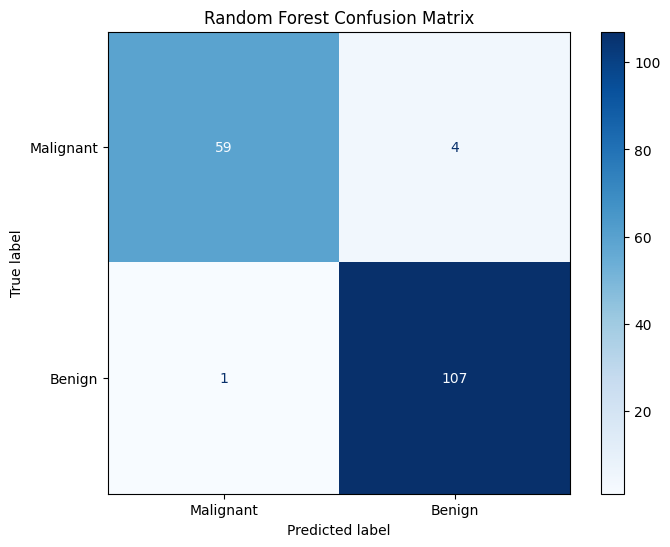

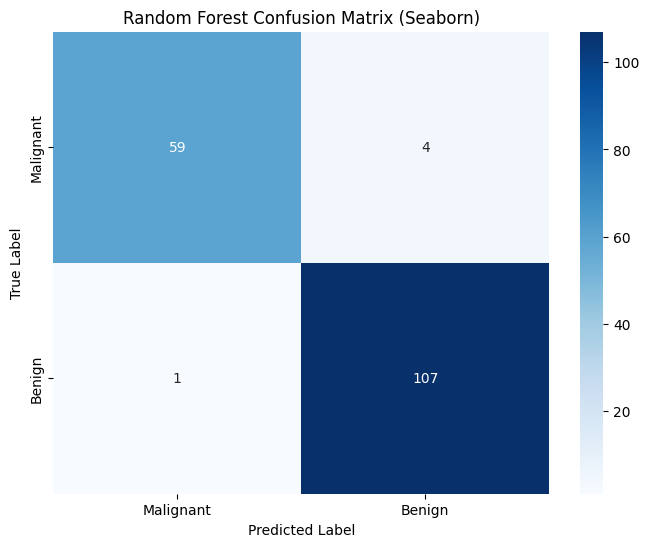

Accuracy: 0.9708
OOB Score: 0.9548
Confusion Matrix:
[[ 59   4]
 [  1 107]]


In [14]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Load Breast Cancer dataset (binary: malignant=0, benign=1)
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Malignant', 'Benign']

# Method 1: Scikit-learn ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

# Method 2: Seaborn heatmap (alternative)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Random Forest Confusion Matrix (Seaborn)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print metrics
print(f"Accuracy: {rf.score(X_test, y_test):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")
print("Confusion Matrix:")
print(cm)


# 36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Define base estimators
estimators = [
    ('dt', DecisionTreeClassifier(random_state=42, max_depth=10)),
    ('svm', make_pipeline(StandardScaler(), SVC(random_state=42, probability=True))),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
]

# Create Stacking Classifier (Logistic Regression as meta-learner)
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

# Train and compare
stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

# Baseline Random Forest for comparison
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Results
print("STACKING CLASSIFIER PERFORMANCE")
print("=" * 50)
print(f"Stacking Accuracy:   {stack_acc:.4f}")
print(f"Random Forest:       {rf_acc:.4f}")
print(f"Stacking Improvement: {((stack_acc-rf_acc)/rf_acc)*100:.1f}%")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

STACKING CLASSIFIER PERFORMANCE
Stacking Accuracy:   0.9825
Random Forest:       0.9708
Stacking Improvement: 1.2%


# 37. Train a Random Forest Classifier and print the top 5 most important features.


In [16]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# Load and prepare data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size=0.3, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

# Get top 5 features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:5]

print("TOP 5 MOST IMPORTANT FEATURES:")
print("=" * 40)
for i in range(5):
    idx = indices[i]
    print(f"{i+1}. {cancer.feature_names[idx]}: {importances[idx]:.4f}")

print(f"\nOverall Accuracy: {rf.score(X_test, y_test):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")


TOP 5 MOST IMPORTANT FEATURES:
1. mean concave points: 0.1419
2. worst concave points: 0.1271
3. worst area: 0.1182
4. mean concavity: 0.0806
5. worst radius: 0.0780

Overall Accuracy: 0.9708
OOB Score: 0.9548


# 38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.


In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Train Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    oob_score=True
)
bagging.fit(X_train, y_train)

# Predict and evaluate
y_pred = bagging.predict(X_test)

# Print comprehensive metrics
print("BAGGING CLASSIFIER PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"OOB Score: {bagging.oob_score_:.4f}\n")

print("DETAILED CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred,
                          target_names=['Malignant', 'Benign']))


BAGGING CLASSIFIER PERFORMANCE
Accuracy: 0.9591
OOB Score: 0.9397

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Malignant       0.95      0.94      0.94        63
      Benign       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



# 39.Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

max_depth=3: Train=0.9774, Test=0.9708
max_depth=6: Train=0.9975, Test=0.9649
max_depth=10: Train=1.0000, Test=0.9708
max_depth=None: Train=1.0000, Test=0.9708


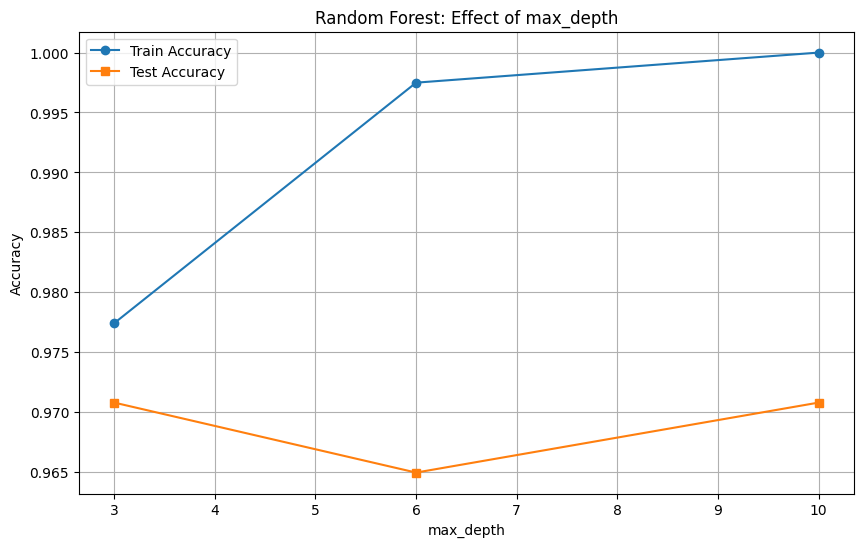

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                   test_size=0.3, random_state=42)

depths = [3, 6, 10, None]
accuracies = []
train_scores = []

for max_depth in depths:
    rf = RandomForestClassifier(n_estimators=100, max_depth=max_depth, random_state=42)
    rf.fit(X_train, y_train)

    train_acc = rf.score(X_train, y_train)
    test_acc = rf.score(X_test, y_test)

    accuracies.append(test_acc)
    train_scores.append(train_acc)

    print(f"max_depth={max_depth}: Train={train_acc:.4f}, Test={test_acc:.4f}")

# Plot bias-variance tradeoff
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Train Accuracy')
plt.plot(depths, accuracies, 's-', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of max_depth')
plt.legend()
plt.grid(True)
plt.show()


# 40. Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.


In [19]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Load Diabetes dataset
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

# Bagging with Decision Tree (high-variance → great bagging candidate)
bag_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=50, random_state=42, oob_score=True
)
bag_dt.fit(X_train, y_train)
dt_pred = bag_dt.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

# Bagging with KNN (low-variance → limited bagging benefit)
bag_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(n_neighbors=5),
    n_estimators=50, random_state=42, oob_score=True
)
bag_knn.fit(X_train, y_train)
knn_pred = bag_knn.predict(X_test)
knn_mse = mean_squared_error(y_test, knn_pred)
knn_r2 = r2_score(y_test, knn_pred)

# Results table
results = pd.DataFrame({
    'Model': ['Bagging(DT)', 'Bagging(KNN)'],
    'Test MSE': [round(dt_mse), round(knn_mse)],
    'R² Score': [round(dt_r2, 3), round(knn_r2, 3)],
    'OOB R²': [round(bag_dt.oob_score_, 3), round(bag_knn.oob_score_, 3)]
})
print(results)


          Model  Test MSE  R² Score  OOB R²
0   Bagging(DT)      2987     0.447   0.424
1  Bagging(KNN)      3140     0.418   0.385


#41. Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

Random Forest ROC-AUC Score: 0.9968
Test Accuracy: 0.9708
OOB Score: 0.9548


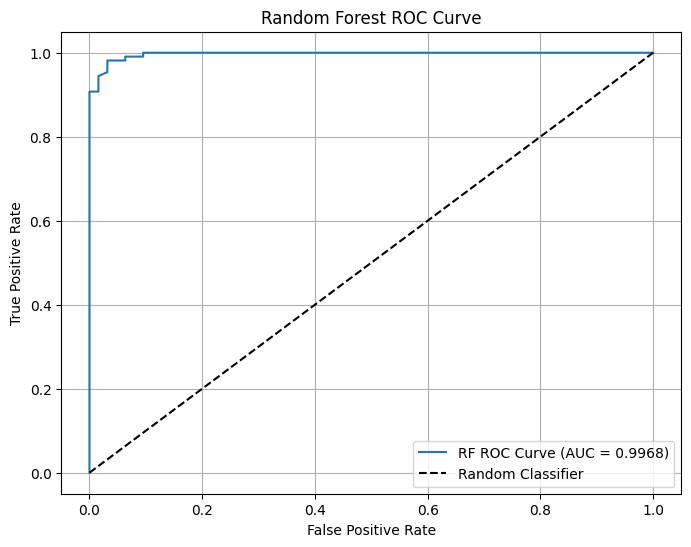

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)

# Get prediction probabilities for positive class (Benign=1)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# Compute ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Random Forest ROC-AUC Score: {roc_auc:.4f}")
print(f"Test Accuracy: {rf.score(X_test, y_test):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")

# ROC Curve visualization
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'RF ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


# 42.  Train a Bagging Classifier and evaluate its performance using cross-validation.

In [21]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Train/test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Bagging Classifier
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    oob_score=True
)

# Cross-validation (5-fold)
cv_scores = cross_val_score(bagging, X, y, cv=5, scoring='accuracy')

# Train final model
bagging.fit(X_train, y_train)
test_accuracy = bagging.score(X_test, y_test)

# Results
print("CROSS-VALIDATION PERFORMANCE")
print("=" * 40)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"OOB Score: {bagging.oob_score_:.4f}")


CROSS-VALIDATION PERFORMANCE
CV Scores: [0.89473684 0.93859649 0.99122807 0.96491228 1.        ]
Mean CV Accuracy: 0.9579 (+/- 0.0764)
Test Accuracy: 0.9591
OOB Score: 0.9397


# 43. Train a Random Forest Classifier and plot the Precision-Recall curve.

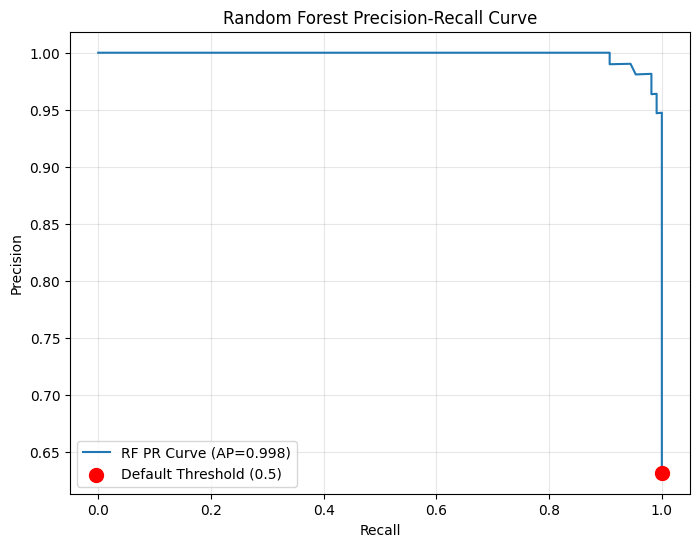

Precision-Recall AUC (AP): 0.9981
Test Accuracy: 0.9708


In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get prediction probabilities for positive class
y_scores = rf.predict_proba(X_test)[:, 1]

# Compute Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
auc_pr = average_precision_score(y_test, y_scores)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'RF PR Curve (AP={auc_pr:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Random Forest Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)

# Mark default threshold (0.5)
default_idx = np.argmax(thresholds <= 0.5)
plt.scatter(recall[default_idx], precision[default_idx],
           color='red', s=100, label='Default Threshold (0.5)', zorder=5)
plt.legend()
plt.show()

# Print key metrics
print(f"Precision-Recall AUC (AP): {auc_pr:.4f}")
print(f"Test Accuracy: {rf.score(X_test, y_test):.4f}")


# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

In [23]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load Breast Cancer dataset
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.3, random_state=42
)

# Base estimators
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', make_pipeline(StandardScaler(), LogisticRegression(random_state=42)))
]

# Stacking Classifier
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42),
    cv=5
)

# Train models for comparison
stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

lr = make_pipeline(StandardScaler(), LogisticRegression(random_state=42))
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Results
print("STACKING vs BASE MODELS")
print("=" * 40)
print(f"Stacking Accuracy:    {stack_acc:.4f}")
print(f"Random Forest:        {rf_acc:.4f}")
print(f"Logistic Regression:  {lr_acc:.4f}")
print(f"Stacking Improvement: {((stack_acc-rf_acc)/rf_acc)*100:.1f}% over RF")


STACKING vs BASE MODELS
Stacking Accuracy:    0.9766
Random Forest:        0.9708
Logistic Regression:  0.9825
Stacking Improvement: 0.6% over RF


# 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

In [24]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Load Diabetes dataset
diabetes = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.3, random_state=42
)

# Test different bootstrap sample sizes (as fraction of training data)
bootstrap_fractions = [0.3, 0.5, 0.7, 1.0]  # 30%, 50%, 70%, 100%
results = []

for max_samples in bootstrap_fractions:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=50,
        max_samples=max_samples,  # Fraction of training samples per tree
        random_state=42,
        oob_score=True
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    oob = model.oob_score_

    results.append({
        'Bootstrap %': f"{int(max_samples*100)}%",
        'Test MSE': mse,
        'R²': r2,
        'OOB R²': oob
    })

    print(f"{max_samples*100:3.0f}% samples | MSE: {mse:.0f} | R²: {r2:.3f} | OOB: {oob:.3f}")

# Summary table
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print(results_df.round(2))


 30% samples | MSE: 2742 | R²: 0.492 | OOB: 0.452
 50% samples | MSE: 2827 | R²: 0.476 | OOB: 0.414
 70% samples | MSE: 2797 | R²: 0.482 | OOB: 0.423
100% samples | MSE: 2987 | R²: 0.447 | OOB: 0.424

  Bootstrap %  Test MSE    R²  OOB R²
0         30%   2741.89  0.49    0.45
1         50%   2826.94  0.48    0.41
2         70%   2797.22  0.48    0.42
3        100%   2987.01  0.45    0.42
